# Exploratory Data Analysis (EDA)
In this notebook, we'll perform EDA on the cleaned landmark dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
data_path = '../data/dataset_landmarks.csv'
df = pd.read_csv(data_path)
df.head()

,label,sequence,frame_idx,image_path,rh_x_0,rh_y_0,rh_z_0,rh_x_1,rh_y_1,rh_z_1,...,rh_z_17,rh_x_18,rh_y_18,rh_z_18,rh_x_19,rh_y_19,rh_z_19,rh_x_20,rh_y_20,rh_z_20
0,buka_kunci,3,0,C:\Users\Yovan\Dataset_Gestur\buka_kunci\3\0.jpg,0.643276,0.783602,1.793145e-07,0.593001,0.735470,-0.018264,...,-0.025088,0.741432,0.577683,-0.040174,0.731554,0.563453,-0.046095,0.710204,0.574009,-0.046895
1,buka_kunci,3,1,C:\Users\Yovan\Dataset_Gestur\buka_kunci\3\1.jpg,0.644096,0.789617,1.382883e-07,0.592615,0.735447,-0.019166,...,-0.024273,0.739397,0.580076,-0.039686,0.728949,0.563906,-0.045525,0.707402,0.572161,-0.046345
2,buka_kunci,3,2,C:\Users\Yovan\Dataset_Gestur\buka_kunci\3\2.jpg,0.643773,0.794315,1.530022e-07,0.593466,0.740763,-0.017364,...,-0.024761,0.745896,0.584282,-0.039054,0.741663,0.560796,-0.046240,0.720992,0.563582,-0.048172
3,buka_kunci,3,3,C:\Users\Yovan\Dataset_Gestur\buka_kunci\3\3.jpg,0.646236,0.796363,8.977479e-08,0.596943,0.740299,-0.016382,...,-0.018549,0.748315,0.591774,-0.033454,0.749857,0.562634,-0.042953,0.739387,0.550762,-0.047940
4,buka_kunci,3,4,C:\Users\Yovan\Dataset_Gestur\buka_kunci\3\4.jpg,0.645583,0.794914,1.460927e-07,0.599876,0.739227,-0.016997,...,-0.021521,0.748350,0.598538,-0.034782,0.756616,0.568611,-0.041946,0.758735,0.538876,-0.046857


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9160 entries, 0 to 9159
Data columns (total 67 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   label       9160 non-null   object 
 1   sequence    9160 non-null   int64  
 2   frame_idx   9160 non-null   int64  
 3   image_path  9160 non-null   object 
 4   rh_x_0      9160 non-null   float64
 5   rh_y_0      9160 non-null   float64
 6   rh_z_0      9160 non-null   float64
 7   rh_x_1      9160 non-null   float64
 8   rh_y_1      9160 non-null   float64
 9   rh_z_1      9160 non-null   float64
 10  rh_x_2      9160 non-null   float64
 11  rh_y_2      9160 non-null   float64
 12  rh_z_2      9160 non-null   float64
 13  rh_x_3      9160 non-null   float64
 14  rh_y_3      9160 non-null   float64
 15  rh_z_3      9160 non-null   float64
 16  rh_x_4      9160 non-null   float64
 17  rh_y_4      9160 non-null   float64
 18  rh_z_4      9160 non-null   float64
 19  rh_x_5      9160 non-null  

## Class Distribution
Checking how many frames and sequences belong to each class.

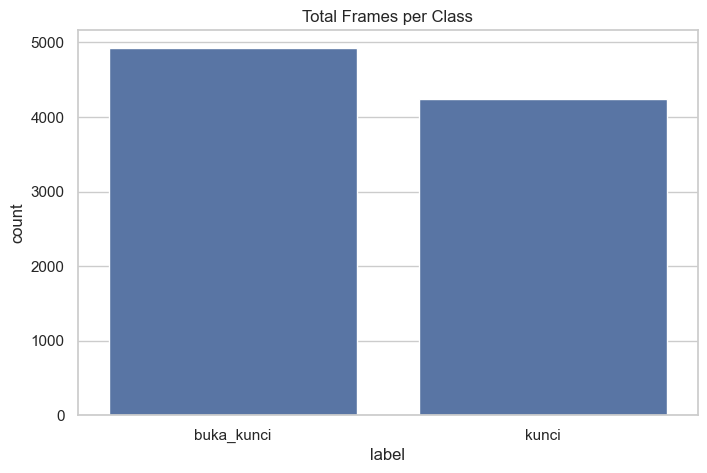

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label')
plt.title('Total Frames per Class')
plt.show()

        label  sequence
0  buka_kunci       123
1       kunci       106


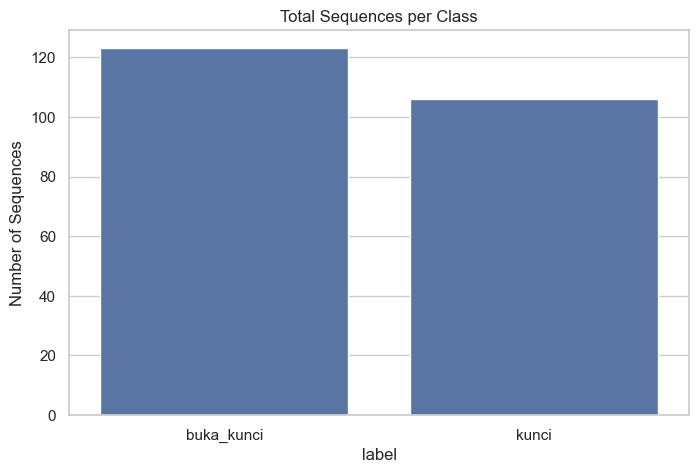

In [5]:
sequences_per_class = df.groupby('label')['sequence'].nunique().reset_index()
print(sequences_per_class)

plt.figure(figsize=(8, 5))
sns.barplot(data=sequences_per_class, x='label', y='sequence')
plt.title('Total Sequences per Class')
plt.ylabel('Number of Sequences')
plt.show()

## Sequence Lengths
Making sure all sequences have uniform length (number of frames).

Unique sequence lengths: [40]


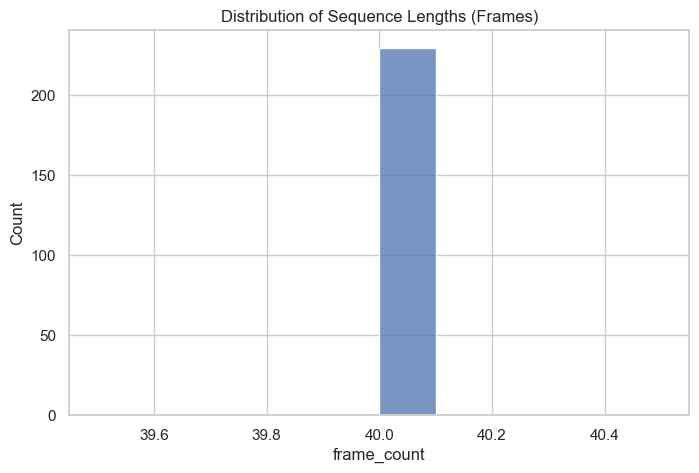

In [6]:
sequence_lengths = df.groupby(['label', 'sequence']).size().reset_index(name='frame_count')
print("Unique sequence lengths:", sequence_lengths['frame_count'].unique())

plt.figure(figsize=(8, 5))
sns.histplot(sequence_lengths['frame_count'], bins=10, kde=False)
plt.title('Distribution of Sequence Lengths (Frames)')
plt.show()

In [7]:
# Additional statistical insights on landmarks
landmark_cols = df.columns[4:]
print("Number of Landmark coordinates:", len(landmark_cols))

df[landmark_cols].describe()

Number of Landmark coordinates: 63


,rh_x_0,rh_y_0,rh_z_0,rh_x_1,rh_y_1,rh_z_1,rh_x_2,rh_y_2,rh_z_2,rh_x_3,...,rh_z_17,rh_x_18,rh_y_18,rh_z_18,rh_x_19,rh_y_19,rh_z_19,rh_x_20,rh_y_20,rh_z_20
count,9160.000000,9160.000000,9.160000e+03,9160.000000,9160.000000,9160.000000,9160.000000,9160.000000,9160.000000,9160.000000,...,9160.000000,9160.000000,9160.000000,9160.000000,9160.000000,9160.000000,9160.000000,9160.000000,9160.000000,9160.000000
mean,0.589938,0.714968,8.185607e-09,0.538492,0.686198,-0.018759,0.497380,0.634815,-0.030393,0.476396,...,-0.035845,0.631313,0.530664,-0.051352,0.632735,0.527501,-0.052171,0.638330,0.516055,-0.050506
std,0.194075,0.154823,3.908930e-07,0.196636,0.152118,0.008077,0.201242,0.150628,0.013403,0.210611,...,0.019606,0.217069,0.154857,0.025660,0.219175,0.163484,0.032134,0.219978,0.171527,0.038522
min,0.059576,0.235038,-1.052008e-06,0.052363,0.251648,-0.057398,0.050892,0.230729,-0.096225,0.045029,...,-0.121493,0.091113,0.062665,-0.173506,0.078857,0.019556,-0.196697,0.068313,-0.017319,-0.211029
25%,0.394310,0.643522,-3.697646e-07,0.344924,0.610803,-0.023137,0.292744,0.559009,-0.038181,0.271987,...,-0.048104,0.426898,0.452673,-0.066590,0.426837,0.432403,-0.072974,0.436483,0.405077,-0.077298
50%,0.611374,0.734808,1.292476e-07,0.572851,0.706956,-0.018048,0.533820,0.658577,-0.029308,0.517348,...,-0.033711,0.662003,0.549916,-0.047366,0.665686,0.542637,-0.045969,0.671790,0.528336,-0.043870
75%,0.769587,0.826712,3.479788e-07,0.726623,0.794357,-0.012949,0.683424,0.737794,-0.020400,0.664799,...,-0.021311,0.826017,0.638475,-0.032033,0.822113,0.640515,-0.026851,0.824797,0.641049,-0.019180
max,0.895917,1.023853,1.212895e-06,0.855142,0.980857,0.014836,0.830215,0.965943,0.017127,0.859943,...,0.034606,0.985569,0.901492,0.032982,1.015484,0.914282,0.027038,1.041455,0.901838,0.024371


## Preprocessing: Sequences
Since this is a dynamic gesture consisting of 40 frames each, we group the rows by their `sequence` ID to obtain data shaping `(Number Of Sequences, 40, 63)`.

In [8]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Ensure consistent order: keep the original chronological sorting (grouped by sequence)
# But wait, 'sequence' is unique *within* a label. Let's create a global unique sequence id.
df['global_seq'] = df['label'] + '_' + df['sequence'].astype(str)

grouped = df.groupby('global_seq')

sequences = []
labels = []

for name, group in grouped:
    if len(group) == 40:  # Enforce strictly 40 frames per sequence
        sequences.append(group.iloc[:, 4:-1].values) # Get only coordinates (skip sequence ids, paths)
        labels.append(group['label'].iloc[0])

X = np.array(sequences)
y = np.array(labels)

print("X shape (Sequences, Frames, Features):", X.shape)
print("y shape:", y.shape)

X shape (Sequences, Frames, Features): (229, 40, 63)
y shape: (229,)


We need to encode the labels to categorical (one-hot) format so Neural Networks can understand them.

In [9]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print("Categories:", label_encoder.classes_)

Categories: ['buka_kunci' 'kunci']


## Train/Test Split & Normalization
We will manually split our data into Training (80%) and Testing (20%), and then perfectly standardize the 3D coordinates so the LSTM can learn the flow easily.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# Remember LSTM requires (samples, timesteps, features). 
# StandardScaler only understands 2D data (samples, features),
# so we briefly reshape our 3D tensor, normalize, and reshape back.

scaler = StandardScaler()

X_train_res = X_train.reshape(-1, X_train.shape[-1])
X_train_res = scaler.fit_transform(X_train_res)
X_train = X_train_res.reshape(X_train.shape)

X_test_res = X_test.reshape(-1, X_test.shape[-1])
X_test_res = scaler.transform(X_test_res)
X_test = X_test_res.reshape(X_test.shape)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (183, 40, 63)
Testing Set: (46, 40, 63)


## Dynamic LSTM Model Training
We construct a model specifically made for dynamic sequences.

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(y_categorical.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\ikhwa\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,914 (136.38 KB)

 Trainable params: 34,914 (136.38 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7432 - loss: 0.5586 - val_accuracy: 0.9348 - val_loss: 0.3568
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9399 - loss: 0.2958 - val_accuracy: 0.9783 - val_loss: 0.1796
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9836 - loss: 0.1474 - val_accuracy: 1.0000 - val_loss: 0.0793
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0611 - val_accuracy: 1.0000 - val_loss: 0.0338
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0249 - val_accuracy: 1.0000 - val_loss: 0.0156
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0135 - val_accuracy: 1.0000 - val_loss: 0.0086
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0088 - val_accuracy: 1.0000 - val_loss: 0.0056
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 1.0000 - v

## Evaluation
Visualizing Model performance and charting the Confusion Matrix.

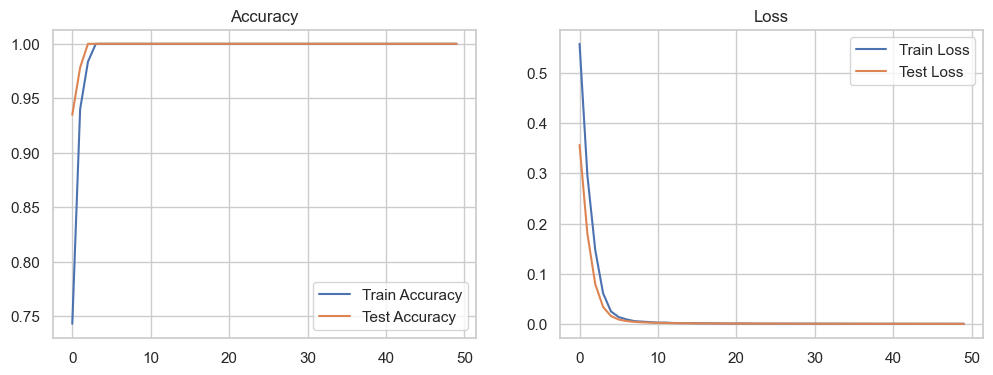

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss')
plt.legend()

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


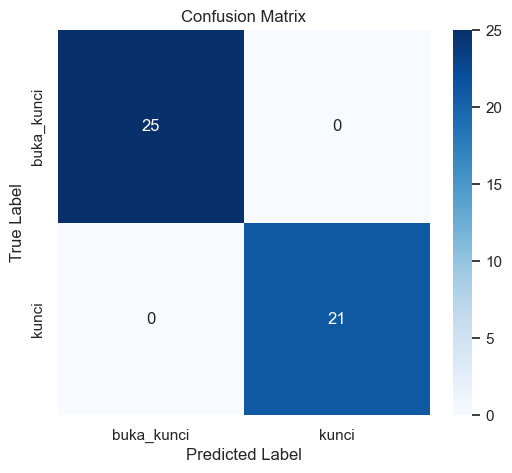

              precision    recall  f1-score   support

  buka_kunci       1.00      1.00      1.00        25
       kunci       1.00      1.00      1.00        21

    accuracy                           1.00        46
   macro avg       1.00      1.00      1.00        46
weighted avg       1.00      1.00      1.00        46



In [14]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

conf_mat = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

## Hyperparameter Tuning / Architecture Variations
Let's run a loop to test multiple configurations (`conf1`, `conf2`, etc.) and automatically compare their Validation Accuracy and Validation Loss curves to see which variation avoids overfitting best!

In [15]:
# Define our variations (Configs)
configs = [
    {'name': 'Conf 1 (Base)', 'layers': [64], 'dense': 32, 'dropout': 0.2},
    {'name': 'Conf 2 (Deep LSTM)', 'layers': [64, 32], 'dense': 32, 'dropout': 0.3},
    {'name': 'Conf 3 (Wide)', 'layers': [128], 'dense': 64, 'dropout': 0.4}
]

histories = {}

for conf in configs:
    print(f"\nTraining {conf['name']}...")
    model = Sequential()
    
    # If Deep architecture (multiple LSTMs)
    if len(conf['layers']) > 1:
        model.add(LSTM(conf['layers'][0], return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(conf['dropout']))
        model.add(LSTM(conf['layers'][1], return_sequences=False))
    else:
        model.add(LSTM(conf['layers'][0], return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
        
    model.add(Dropout(conf['dropout']))
    model.add(Dense(conf['dense'], activation='relu'))
    model.add(Dense(y_categorical.shape[1], activation='softmax'))
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train (verbose=0 so it doesn't spam the notebook)
    history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test), verbose=0)
    histories[conf['name']] = history
    
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Final Test Acc: {acc*100:.2f}% | Loss: {loss:.4f}")


Training Conf 1 (Base)...


c:\Users\ikhwa\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Final Test Acc: 100.00% | Loss: 0.0005

Training Conf 2 (Deep LSTM)...
Final Test Acc: 100.00% | Loss: 0.0006

Training Conf 3 (Wide)...
Final Test Acc: 100.00% | Loss: 0.0002


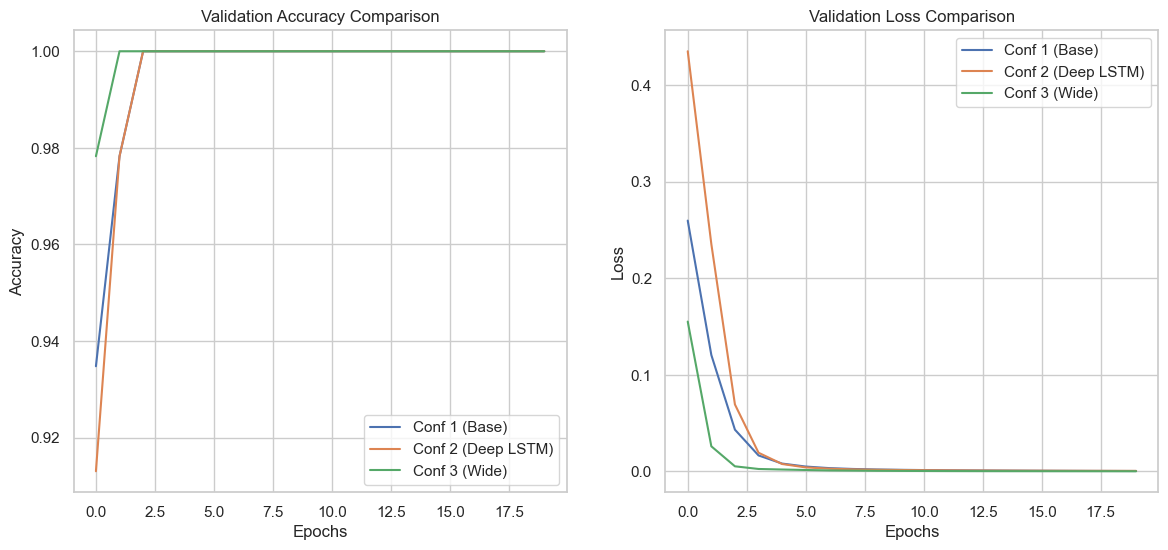

In [16]:
# Plotting the comparison
plt.figure(figsize=(14, 6))

# Validation Accuracy
plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Validation Loss
plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=name)
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Phase 2: Hyperparameter Tuning (Epochs & Batch Size)
Berdasarkan kesepakatan uji coba, kita akan mencari kombinasi `epoch` dan `batch_size` terbaik menggunakan arsitektur base. Variasi klasifikasinya adalah:
- Batch 16, Epoch 30
- Batch 16, Epoch 50
- Batch 32, Epoch 30
- Batch 32, Epoch 50

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# Define the Batch and Epoch variations
tuning_configs = [
    {'name': 'B16_E30', 'batch_size': 16, 'epochs': 30},
    {'name': 'B16_E50', 'batch_size': 16, 'epochs': 50},
    {'name': 'B32_E30', 'batch_size': 32, 'epochs': 30},
    {'name': 'B32_E50', 'batch_size': 32, 'epochs': 50}
]

tuning_histories = {}
tuning_results = {}

for conf in tuning_configs:
    print(f"\nTraining {conf['name']} (Batch: {conf['batch_size']}, Epochs: {conf['epochs']})...")
    
    # Using Base Architecture (Conf 1)
    model_tune = Sequential()
    model_tune.add(LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
    model_tune.add(Dropout(0.2))
    model_tune.add(Dense(32, activation='relu'))
    model_tune.add(Dense(y_categorical.shape[1], activation='softmax'))
    
    model_tune.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    history = model_tune.fit(
        X_train, y_train, 
        epochs=conf['epochs'], 
        batch_size=conf['batch_size'], 
        validation_data=(X_test, y_test), 
        verbose=0
    )
    tuning_histories[conf['name']] = history
    
    loss, acc = model_tune.evaluate(X_test, y_test, verbose=0)
    tuning_results[conf['name']] = acc
    print(f"Final Test Acc for {conf['name']}: {acc*100:.2f}% | Loss: {loss:.4f}")


Training B16_E30 (Batch: 16, Epochs: 30)...
Final Test Acc for B16_E30: 100.00% | Loss: 0.0009

Training B16_E50 (Batch: 16, Epochs: 50)...
Final Test Acc for B16_E50: 100.00% | Loss: 0.0006

Training B32_E30 (Batch: 32, Epochs: 30)...
Final Test Acc for B32_E30: 100.00% | Loss: 0.0009

Training B32_E50 (Batch: 32, Epochs: 50)...
Final Test Acc for B32_E50: 100.00% | Loss: 0.0003


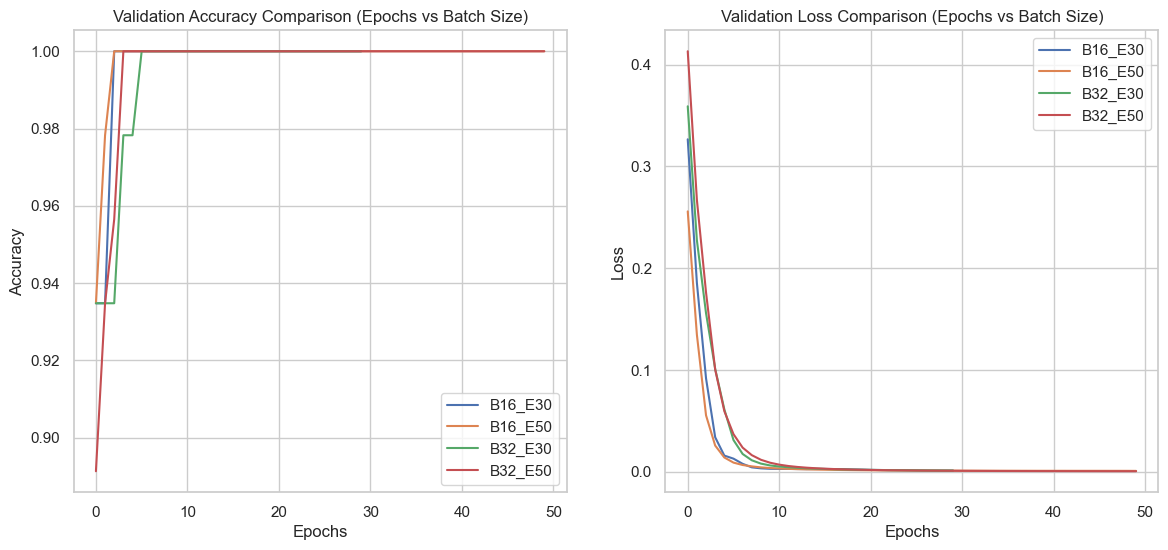

In [18]:
# Plotting the Phase 2 comparison
plt.figure(figsize=(14, 6))

# Validation Accuracy
plt.subplot(1, 2, 1)
for name, history in tuning_histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison (Epochs vs Batch Size)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Validation Loss
plt.subplot(1, 2, 2)
for name, history in tuning_histories.items():
    plt.plot(history.history['val_loss'], label=name)
plt.title('Validation Loss Comparison (Epochs vs Batch Size)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Phase 3: Train and Save the Final Best Model
Berdasarkan analisis, model paling optimal adalah **Arch Base (1 LSTM layer 64 unit)** dengan parameter **Batch Size 16 dan Epoch 30**.
Mari kita latih untuk yang terakhir kalinya dengan parameter tersebut lalu menyimpan file `.h5` nya ke direktori `artifacts/`.

In [19]:
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Create artifacts directory if it doesn't exist
os.makedirs('../artifacts', exist_ok=True)

print("Training Final Best Model (Base Arch, Batch 16, Epoch 30)...")
final_model = Sequential()
final_model.add(LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
final_model.add(Dropout(0.2))
final_model.add(Dense(32, activation='relu'))
final_model.add(Dense(y_categorical.shape[1], activation='softmax'))

final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

final_model.fit(
    X_train, y_train, 
    epochs=30, 
    batch_size=16, 
    validation_data=(X_test, y_test), 
    verbose=1
)

loss, acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {acc*100:.2f}%")

# Save the model!
model_path = '../artifacts/best_model.h5'
final_model.save(model_path)
print(f"Model successfully saved to {model_path}")

Training Final Best Model (Base Arch, Batch 16, Epoch 30)...
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8142 - loss: 0.4788 - val_accuracy: 0.9348 - val_loss: 0.2971
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9508 - loss: 0.2230 - val_accuracy: 0.9565 - val_loss: 0.1604
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9836 - loss: 0.1158 - val_accuracy: 1.0000 - val_loss: 0.0509
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0453 - val_accuracy: 1.0000 - val_loss: 0.0228
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0170 - val_accuracy: 1.0000 - val_loss: 0.0116
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0082 - val_accuracy: 1.0000 - val_loss: 0.0073
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.0048
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


Final Test Accuracy: 100.00%
Model successfully saved to ../artifacts/best_model.h5
